In [8]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()
groq_api_key = os.getenv("GROQ_API_KEY")
llm = ChatGroq(
    api_key=groq_api_key,
    model="openai/gpt-oss-120b"
)
# result = llm.invoke("What is the capital of France?")
# print(result)

C:\Users\ybalasaraswa\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

class State(TypedDict):
    topic: str
    story: str
    improved_story: str
    final_story: str

##Nodes
def generate_story(state: State):
    story_prompt = f"Write a short story about {state['topic']} in 100 words."
    story = llm.invoke(story_prompt)
    return {"story": story.content}

def check_conflict(state:State):
    if "?" in state["story"] or "!" in state["story"]:
        return "Fail"
    else:
        return "Pass"

def improved_story(state:State):
    msg = llm.invoke(f"Improve the following story: {state['story']}")
    return {"improved_story": msg.content}

def polish_story(state:State):
    msg = llm.invoke(f"Polish the following story: {state['improved_story']}")
    return {"final_story": msg.content}

In [10]:
#Build the Graph
graph = StateGraph(State)
graph.add_node("Generate_Story", generate_story)
# graph.add_node("Check_Conflict", check_conflict)
graph.add_node("Improved_Story", improved_story)
graph.add_node("Polish_Story", polish_story)

#edges
graph.add_edge(START, "Generate_Story")
graph.add_conditional_edges(
    "Generate_Story", check_conflict, {
        "Pass": "Improved_Story",
        "Fail": "Generate_Story"
    }
   )
graph.add_edge("Improved_Story", "Polish_Story")
graph.add_edge("Polish_Story", END)

compiled_graph = graph.compile()


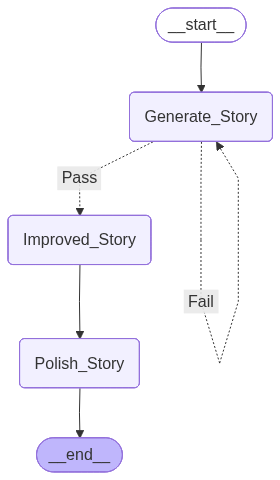

In [11]:
try:
   display(Image(compiled_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization is not supported in this environment.")

In [13]:
result = compiled_graph.invoke({"topic": "crow and pebbels"})

print("=" * 60)
print("📖  STORY GENERATION PIPELINE")
print("=" * 60)
print(f"\n🎯  Topic       : {result['topic']}")
print("\n📝  Story       :")
print(result['story'])
print("\n✨  Improved    :")
print(result['improved_story'])
print("\n🌟  Final Story :")
print(result['final_story'])
print("\n" + "=" * 60)

📖  STORY GENERATION PIPELINE

🎯  Topic       : crow and pebbels

📝  Story       :
The crow perched on the rusted fence, eyeing the river below. He remembered the old trick: drop a pebble, watch ripples spread, lure fish. Today, he gathered smooth stones, each cold against his beak. One by one, he tossed them into the water, listening to the splash like tiny drums. A silver fish rose, startled, then darted away. Frustrated, the crow cawed, but a sudden gust lifted a larger pebble toward the surface, creating a massive wave that knocked the fish back into his reach. He snatched the prize, feeling triumph echo in his feathers. He flew home, victorious again.

✨  Improved    :
**The Crow’s River Ruse**

Perched on a rust‑streaked fence that knifed the sky, the crow surveyed the river below with a glint of calculation in his black eyes. The water stretched like a polished slate, its surface rippling ever so slightly with the whisper of the wind. He recalled the old trick his father had taug